<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/dispersi%C3%B3n_correlacion_y_r_square_de_datos_llamadas_y_ventas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Los datos con las librerías necesarias para la correcta ejecución.

In [1]:
import numpy as np
import pandas as pd

llamadas = [96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84]
ventas = [41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30]

datos = pd.DataFrame({
    "llamadas": llamadas,
    "ventas": ventas
})

datos

,llamadas,ventas
0,96,41
1,40,41
2,104,51
3,128,60
4,164,61
5,76,29
6,72,39
7,80,50
8,36,28
9,84,43


Función para calcular covarianza, correlación y R²

In [2]:
def f_cov_corr_r_square(datos, independiente, dependiente):

    x = datos[independiente]
    y = datos[dependiente]

    covarianza = np.cov(x, y)[0,1]
    correlacion = np.corrcoef(x, y)[0,1]
    r_square = correlacion**2

    resultado = pd.DataFrame({
        "Estadistico": ["Covarianza", "Correlación Pearson", "R square"],
        "Valor": [
            round(covarianza,4),
            round(correlacion,4),
            round(r_square,4)
        ]
    })

    return resultado

Llamando la función


In [3]:
resultado = f_cov_corr_r_square(datos, "llamadas", "ventas")
resultado

,Estadistico,Valor
0,Covarianza,476.5714
1,Correlación Pearson,0.8646
2,R square,0.7476


Se crea y se manda llamar la función *f_diagrama_dispersion()* para presentar el diagrama de dispersión y los estadísticos de relación haciendo uso de la librería *matplotlib.pyplot* con su alias *plt*.

In [4]:
import matplotlib.pyplot as plt

def f_diagrama_dispersion(datos, x, y):

    media_x = datos[x].mean()
    media_y = datos[y].mean()

    r = datos[x].corr(datos[y])
    r_square = r**2

    plt.figure(figsize=(8,6))

    plt.scatter(datos[x], datos[y], color="red")

    plt.axvline(media_x, color="blue")
    plt.axhline(media_y, color="blue")

    plt.title(
        f"Dispersión {x} y {y}",
        fontsize=14
    )

    plt.suptitle(
        f"Media {x}={media_x:.2f} ; Media {y}={media_y:.2f} ; r={r:.3f} ; R²={r_square:.3f}",
        fontsize=10
    )

    plt.xlabel(x)
    plt.ylabel(y)

    plt.show()

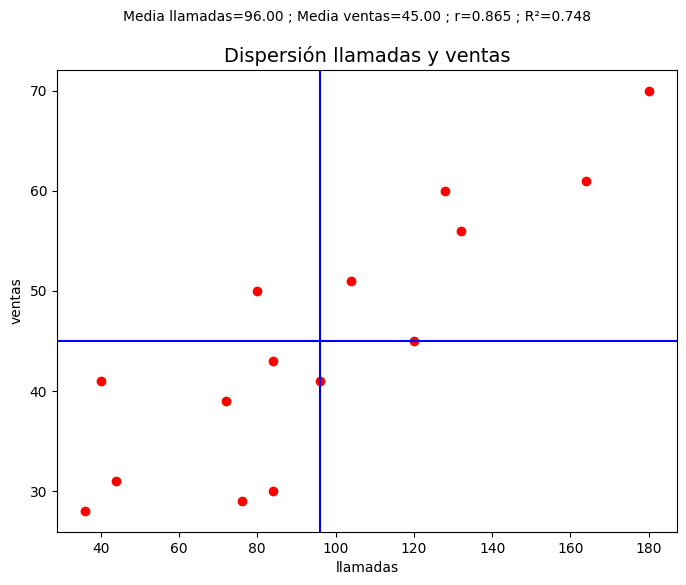

In [5]:
f_diagrama_dispersion(datos, "llamadas", "ventas")